# Matplotlib & Seaborn Visualization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/00-foundations/python-essentials/04_matplotlib_seaborn.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Matplotlib basics: lines, scatter, bar, histogram
- Seaborn for statistical plots
- Customizing plots for presentations
- When to use which plot type

## Why Visualization?

Data always lies to you. Visualization catches what statistics miss. You'll use these plots in every EDA and to explain results to stakeholders.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Matplotlib: 3.10.0
Seaborn: 0.13.2


In [2]:
# Create sample data
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'age': np.random.randint(20, 65, n),
    'income': np.random.randint(30000, 150000, n),
    'experience': np.random.randint(0, 35, n),
    'education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n),
    'department': np.random.choice(['Sales', 'Engineering', 'Marketing', 'HR'], n),
    'performance': np.random.uniform(1, 5, n)
})

df.head()

,age,income,experience,education,department,performance
0,58,145386,2,PhD,Engineering,1.845792
1,48,56736,17,High School,Sales,2.309989
2,34,124209,24,High School,Sales,1.479049
3,62,133041,30,Bachelor,HR,4.562109
4,27,142859,2,PhD,HR,3.374370


---
## 1. Matplotlib Basics

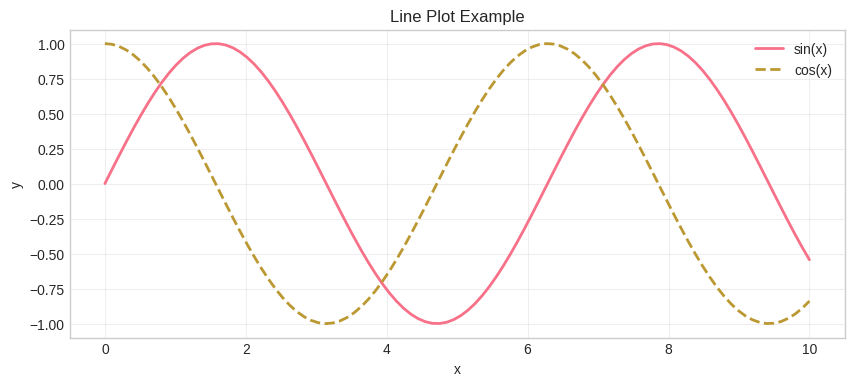

In [3]:
# Line plot
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y1, label='sin(x)', linewidth=2)
plt.plot(x, y2, label='cos(x)', linewidth=2, linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Line Plot Example')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

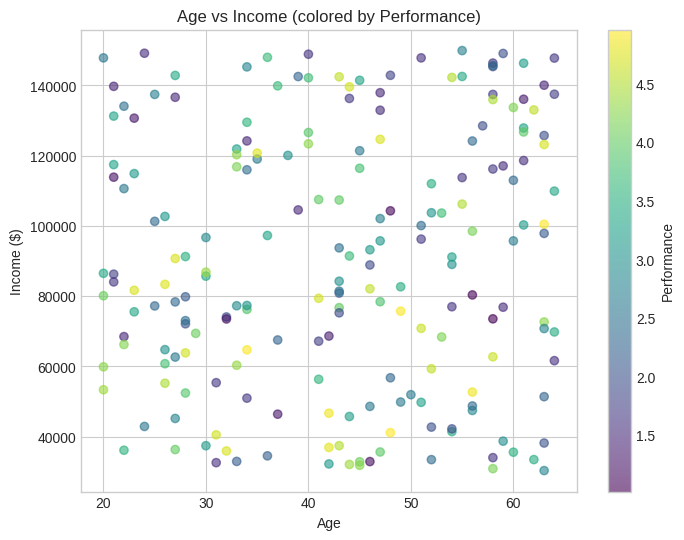

In [4]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['income'], alpha=0.6, c=df['performance'], cmap='viridis')
plt.colorbar(label='Performance')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.title('Age vs Income (colored by Performance)')
plt.show()

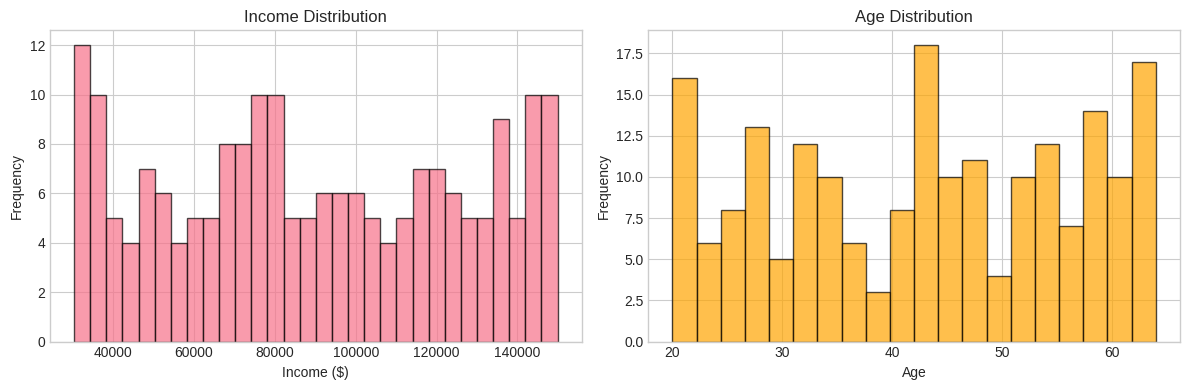

In [5]:
# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['income'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Income Distribution')

axes[1].hist(df['age'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Age Distribution')

plt.tight_layout()
plt.show()

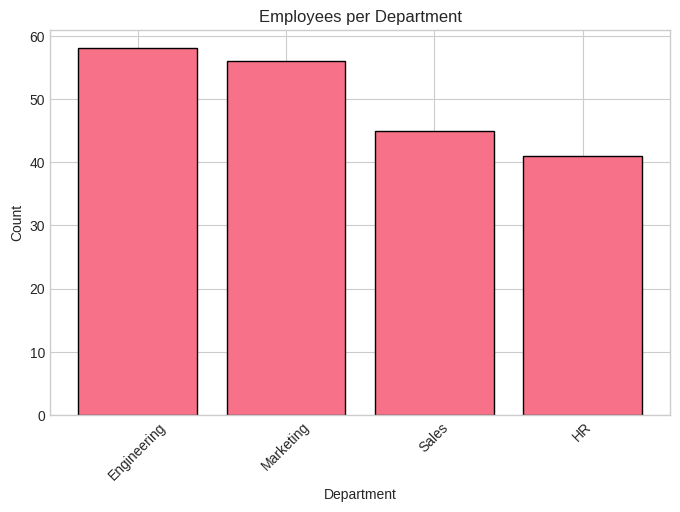

In [6]:
# Bar chart
dept_counts = df['department'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(dept_counts.index, dept_counts.values, edgecolor='black')
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Employees per Department')
plt.xticks(rotation=45)
plt.show()

---
## 2. Subplots

/tmp/ipython-input-3925689471.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(dept_data, labels=df['department'].unique())


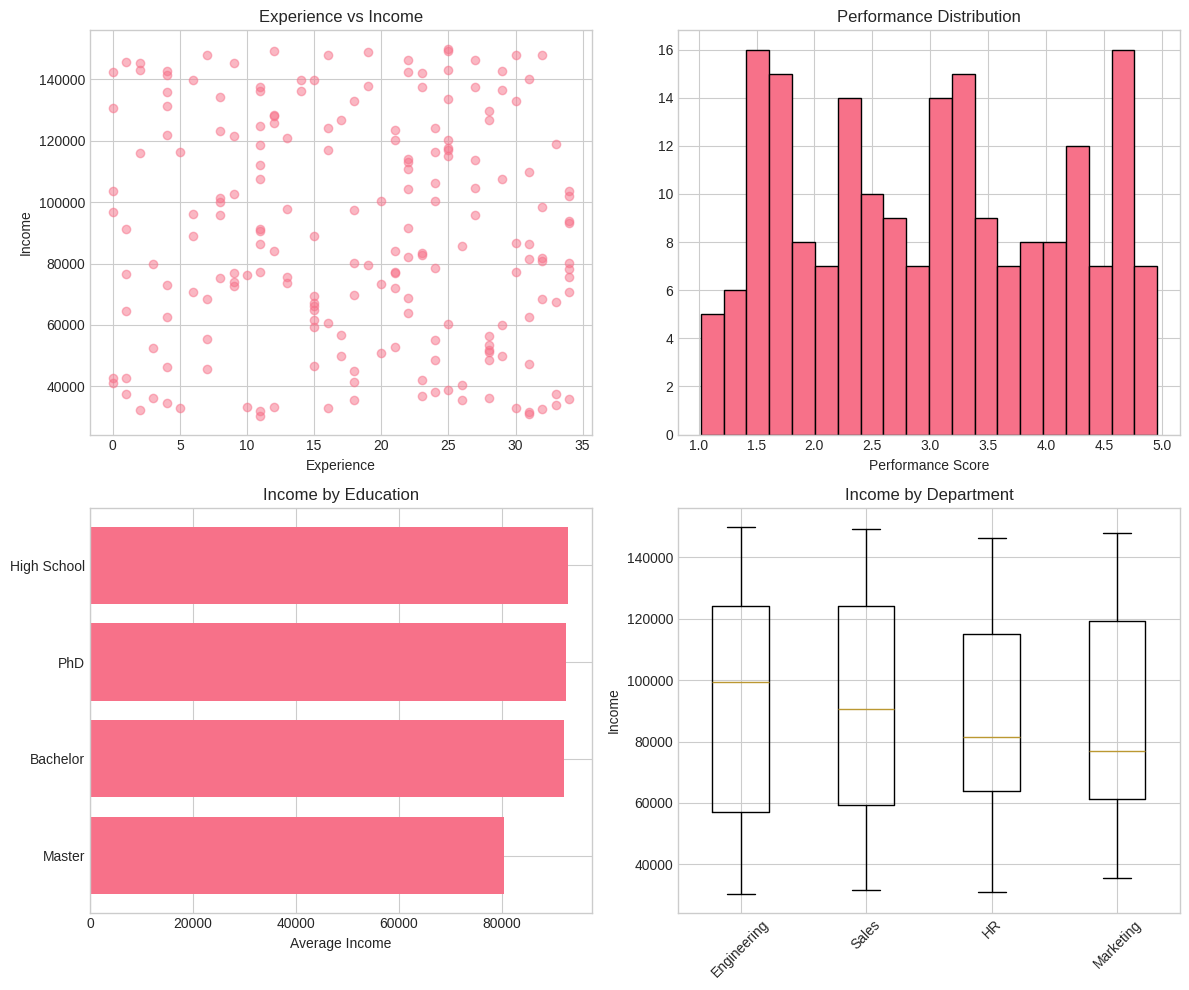

In [7]:
# Multiple plots in one figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Scatter
axes[0, 0].scatter(df['experience'], df['income'], alpha=0.5)
axes[0, 0].set_xlabel('Experience')
axes[0, 0].set_ylabel('Income')
axes[0, 0].set_title('Experience vs Income')

# Plot 2: Histogram
axes[0, 1].hist(df['performance'], bins=20, edgecolor='black')
axes[0, 1].set_xlabel('Performance Score')
axes[0, 1].set_title('Performance Distribution')

# Plot 3: Bar
edu_income = df.groupby('education')['income'].mean().sort_values()
axes[1, 0].barh(edu_income.index, edu_income.values)
axes[1, 0].set_xlabel('Average Income')
axes[1, 0].set_title('Income by Education')

# Plot 4: Box plot
dept_data = [df[df['department'] == d]['income'] for d in df['department'].unique()]
axes[1, 1].boxplot(dept_data, labels=df['department'].unique())
axes[1, 1].set_ylabel('Income')
axes[1, 1].set_title('Income by Department')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Seaborn - Statistical Visualization

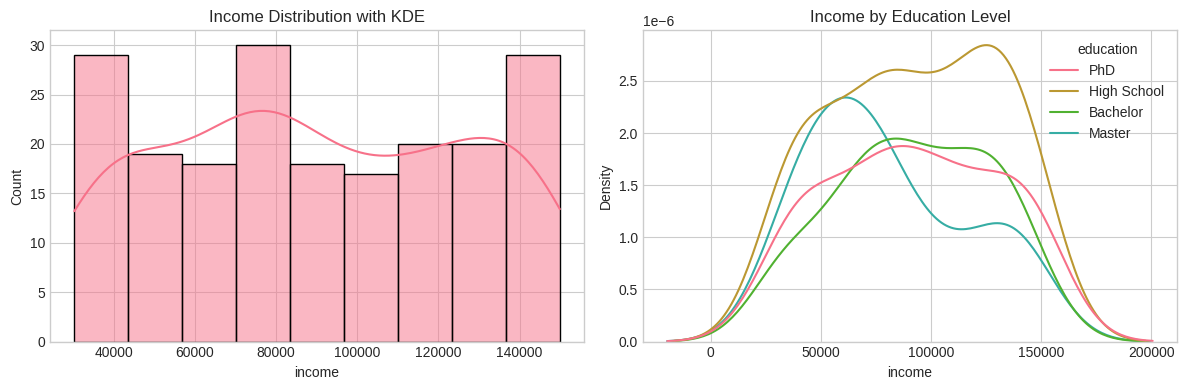

In [8]:
# Distribution plot with KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['income'], kde=True, ax=axes[0])
axes[0].set_title('Income Distribution with KDE')

sns.kdeplot(data=df, x='income', hue='education', ax=axes[1])
axes[1].set_title('Income by Education Level')

plt.tight_layout()
plt.show()

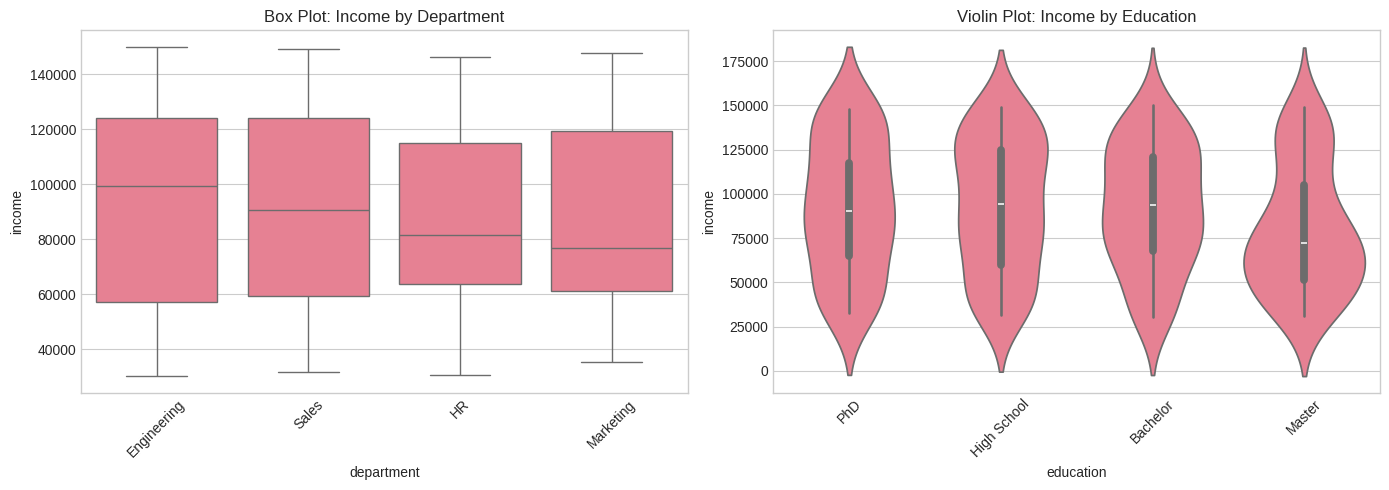

In [9]:
# Box plot and Violin plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='department', y='income', ax=axes[0])
axes[0].set_title('Box Plot: Income by Department')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=df, x='education', y='income', ax=axes[1])
axes[1].set_title('Violin Plot: Income by Education')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

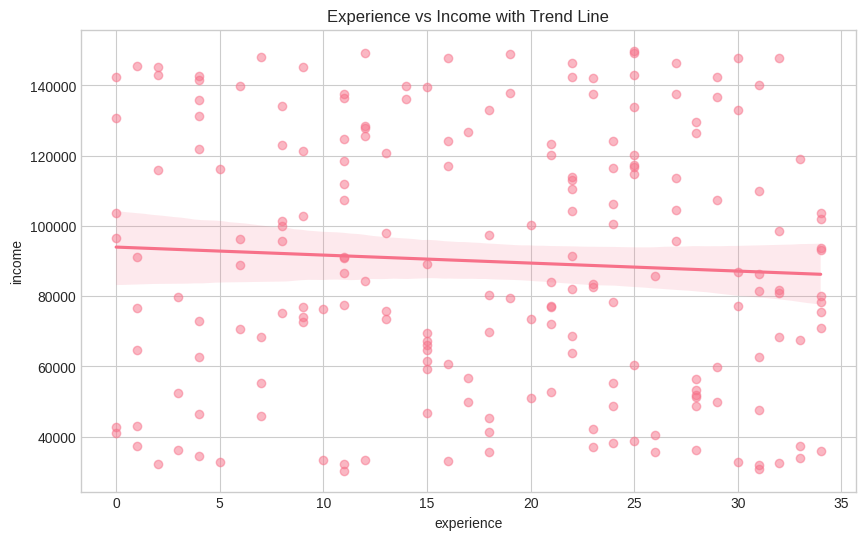

In [10]:
# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='experience', y='income', scatter_kws={'alpha': 0.5})
plt.title('Experience vs Income with Trend Line')
plt.show()

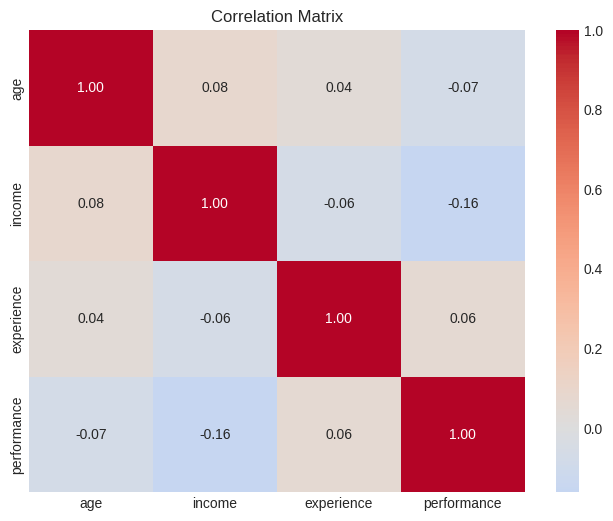

In [11]:
# Heatmap - correlation matrix
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

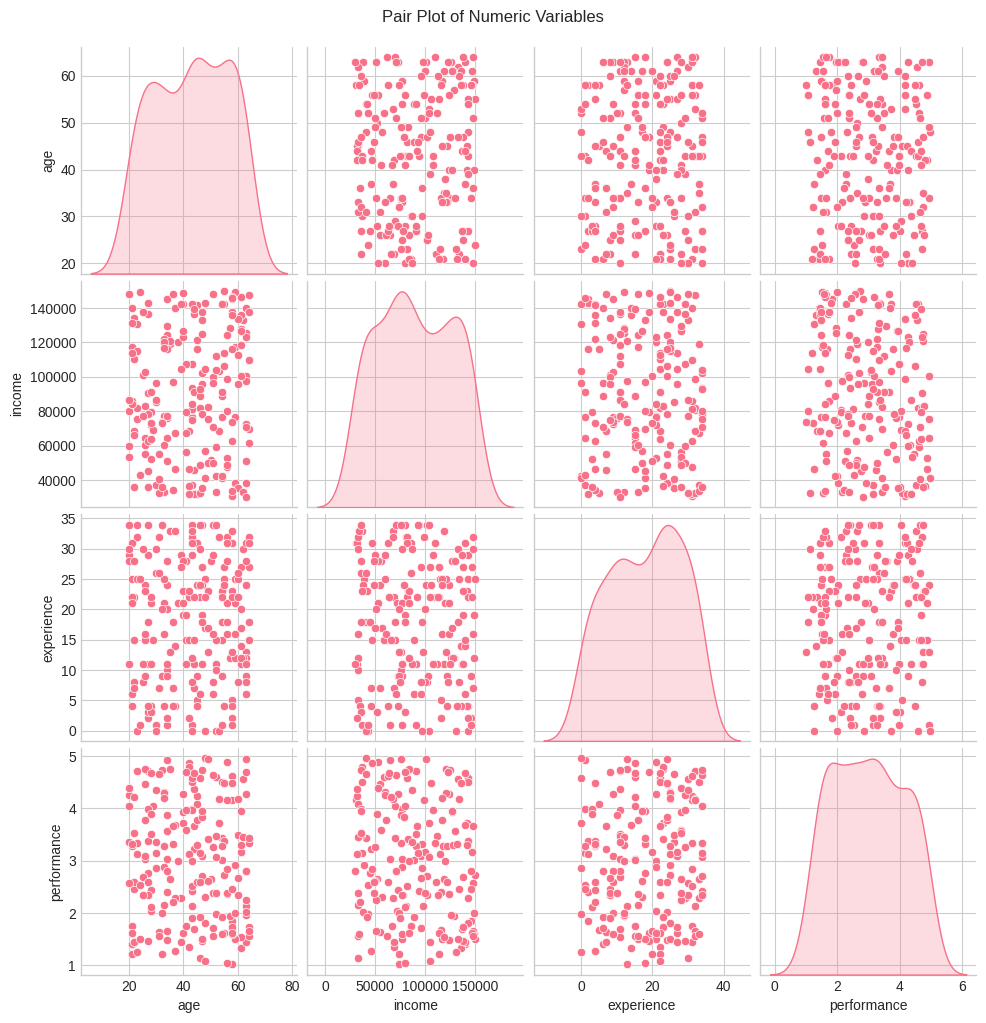

In [12]:
# Pair plot - all relationships at once
sns.pairplot(df[['age', 'income', 'experience', 'performance']], diag_kind='kde')
plt.suptitle('Pair Plot of Numeric Variables', y=1.02)
plt.show()

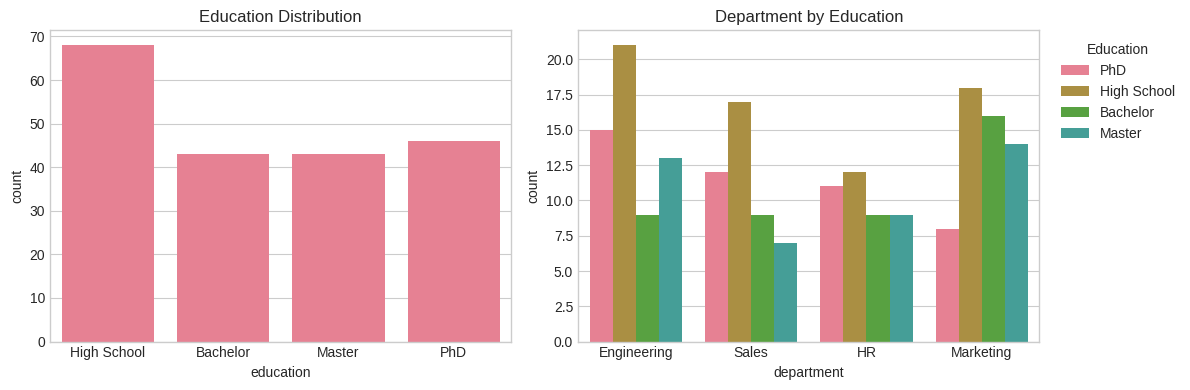

In [13]:
# Count plot for categorical data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='education', order=['High School', 'Bachelor', 'Master', 'PhD'], ax=axes[0])
axes[0].set_title('Education Distribution')

sns.countplot(data=df, x='department', hue='education', ax=axes[1])
axes[1].set_title('Department by Education')
axes[1].legend(title='Education', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

---
## 4. When to Use Which Plot

| Data Type | Best Plot |
|-----------|----------|
| Distribution (1 variable) | Histogram, KDE |
| Compare groups | Box plot, Violin plot |
| Relationship (2 numeric) | Scatter, Regplot |
| Trend over time | Line plot |
| Category counts | Bar chart, Count plot |
| All correlations | Heatmap |
| Overview of data | Pair plot |

---
## 5. Saving Plots

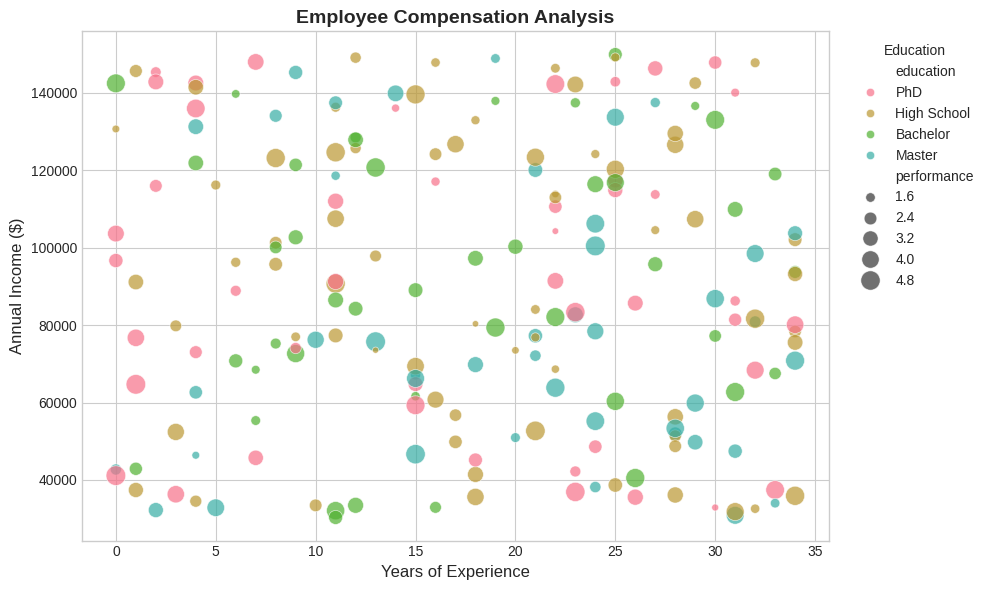

In [14]:
# Create a publication-ready figure
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='experience', y='income', hue='education', size='performance',
                sizes=(20, 200), alpha=0.7, ax=ax)

ax.set_xlabel('Years of Experience', fontsize=12)
ax.set_ylabel('Annual Income ($)', fontsize=12)
ax.set_title('Employee Compensation Analysis', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), title='Education')

plt.tight_layout()

# Save in different formats
# plt.savefig('figure.png', dpi=300, bbox_inches='tight')
# plt.savefig('figure.pdf', bbox_inches='tight')

plt.show()

---
## Quick Reference

| Task | Matplotlib | Seaborn |
|------|------------|--------|
| Scatter | `plt.scatter(x, y)` | `sns.scatterplot(data, x, y)` |
| Line | `plt.plot(x, y)` | `sns.lineplot(data, x, y)` |
| Histogram | `plt.hist(data)` | `sns.histplot(data)` |
| Bar | `plt.bar(x, height)` | `sns.barplot(data, x, y)` |
| Box | `plt.boxplot(data)` | `sns.boxplot(data, x, y)` |
| Heatmap | - | `sns.heatmap(matrix)` |

---
## Your Turn

1. Create a 2x2 subplot showing: histogram, boxplot, scatter, and heatmap
2. Customize colors, labels, and titles
3. Add a trend line to the scatter plot

In [15]:
# Your code here